In [1]:
# Load the libraries and locate the project
import hashlib
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.metrics import precision_score, recall_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

current = Path.cwd()
project = current.parent if current.name == "notebooks" else current

In [2]:
# Load the prepared CSV and tuning settings
data_file = project / "notebooks" / "prepared_network_traffic.csv"
settings_path = project / "notebooks" / "tuning_results.csv"
if not data_file.is_file():
    raise FileNotFoundError("Run data_preprocessing.ipynb first")
if not settings_path.is_file():
    raise FileNotFoundError("Run hyperparameter_tuning.ipynb first")
prepared = pd.read_csv(data_file)
tuning = pd.read_csv(settings_path, dtype={"prepared_csv_sha256": "string"})
if len(tuning) != 1:
    raise ValueError("Tuning CSV must contain one settings row")
with data_file.open("rb") as file:
    prepared_sha256 = hashlib.file_digest(file, "sha256").hexdigest()
if tuning.iloc[0]["prepared_csv_sha256"] != prepared_sha256:
    raise ValueError("Run hyperparameter_tuning.ipynb again for this prepared CSV")

In [3]:
# Validate CSV columns and decode tuning settings
row = tuning.iloc[0]
settings = {
    "logistic_regression_C": float(row["logistic_regression_C"]),
    "random_forest_max_depth": None if pd.isna(row["random_forest_max_depth"]) else int(row["random_forest_max_depth"]),
    "logistic_cv_f1": float(row["logistic_cv_f1"]),
    "forest_cv_f1": float(row["forest_cv_f1"]),
    "prepared_csv_sha256": prepared_sha256,
}
required = {"Label", "time_group", "split"}
if not required.issubset(prepared.columns):
    raise ValueError("Prepared CSV is missing Label, time_group, or split")
candidate_names = [name for name in prepared if name not in required]
if len(candidate_names) != 10:
    raise ValueError("Prepared CSV must contain exactly 10 fixed features")

In [4]:
# Select the train, validation, and test rows
train = prepared["split"].eq("train")
validation = prepared["split"].eq("validation")
test = prepared["split"].eq("test")
if not (train.any() and validation.any() and test.any() and (train | validation | test).all()):
    raise ValueError("Prepared CSV must contain only nonempty train, validation, and test splits")
groups = [set(prepared.loc[mask, "time_group"]) for mask in (train, validation, test)]
if groups[0] & groups[1] or groups[0] & groups[2] or groups[1] & groups[2]:
    raise ValueError("A time group appears in more than one split")
X = prepared[candidate_names]
y = prepared["Label"].astype(int)
if set(y) != {0, 1}:
    raise ValueError("Prepared labels must be 0 for BENIGN and 1 for DDoS")
X_train, y_train = X.loc[train], y.loc[train]
X_val, y_val = X.loc[validation], y.loc[validation]
X_test, y_test = X.loc[test], y.loc[test]

# The prepared CSV already contains the fixed 10 features.
feature_names = candidate_names
X_trainval, y_trainval = X.loc[train | validation, feature_names], y.loc[train | validation]
print("Fixed 10 features:", feature_names)
print("Train:", len(X_train), "Validation:", len(X_val), "Test:", len(X_test))

Fixed 10 features: ['Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Mean', 'Bwd Packet Length Min', 'Fwd IAT Total', 'Fwd IAT Std', 'act_data_pkt_fwd', 'Bwd Header Length']
Train: 139968 Validation: 40208 Test: 45567


In [5]:
# Build Logistic Regression
# Fill missing values and scale the numbers before classification.
logistic_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        C=settings["logistic_regression_C"], max_iter=1000, random_state=42
    )),
])
print(logistic_model)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])


In [6]:
# Build Random Forest with 100 trees
# Fill missing values, then combine 100 decision trees.
forest_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=100, max_depth=settings["random_forest_max_depth"],
        n_jobs=2, random_state=42
    )),
])
print(forest_model)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('model',
                 RandomForestClassifier(max_depth=16, n_jobs=2,
                                        random_state=42))])


In [7]:
# Train Logistic Regression
logistic_model.fit(X_train, y_train)
print("Logistic Regression trained")

Logistic Regression trained


In [8]:
# Train Random Forest
forest_model.fit(X_train, y_train)
print("Random Forest trained")

Random Forest trained


In [9]:
# Compare on validation flows
logistic_val = logistic_model.predict(X_val)
forest_val = forest_model.predict(X_val)
validation_f1 = {
    "random_forest": float(f1_score(y_val, forest_val)),
    "logistic_regression": float(f1_score(y_val, logistic_val)),
}
selected_model = max(validation_f1, key=validation_f1.get)
print("Validation DDoS F1:", validation_f1)
print("Higher validation score:", selected_model)
print("Random Forest validation matrix:", confusion_matrix(y_val, forest_val))
print("Logistic Regression validation matrix:", confusion_matrix(y_val, logistic_val))

Validation DDoS F1: {'random_forest': 0.9995942381821871, 'logistic_regression': 0.9713484588195802}
Higher validation score: random_forest
Random Forest validation matrix: [[15553     8]
 [   12 24635]]
Logistic Regression validation matrix: [[14161  1400]
 [   51 24596]]


In [10]:
# Refit both models on all development flows
logistic_model.fit(X_trainval, y_trainval)
forest_model.fit(X_trainval, y_trainval)
print("Final fit rows:", len(X_trainval))

Final fit rows: 180176


In [11]:
# Predict the untouched test flows
logistic_predictions = logistic_model.predict(X_test)
forest_predictions = forest_model.predict(X_test)
print("Predictions made for", len(X_test), "test flows")

Predictions made for 45567 test flows


In [12]:
# Show the confusion matrices
logistic_matrix = confusion_matrix(y_test, logistic_predictions, labels=[0, 1])
forest_matrix = confusion_matrix(y_test, forest_predictions, labels=[0, 1])
print("Rows: actual BENIGN, DDoS; columns: predicted BENIGN, DDoS")
print("Logistic Regression:", logistic_matrix)
print("Random Forest:", forest_matrix)

Rows: actual BENIGN, DDoS; columns: predicted BENIGN, DDoS
Logistic Regression: [[16859  2341]
 [   40 26327]]
Random Forest: [[19191     9]
 [   14 26353]]


In [13]:
# Calculate the test scores
# False alarm: BENIGN called DDoS. Missed attack: DDoS called BENIGN.
def scores(predictions, matrix):
    tn, fp, fn, tp = matrix.ravel()
    return {
        "accuracy": float(accuracy_score(y_test, predictions)),
        "ddos_precision": float(precision_score(y_test, predictions, zero_division=0)),
        "ddos_recall": float(recall_score(y_test, predictions, zero_division=0)),
        "ddos_f1": float(f1_score(y_test, predictions, zero_division=0)),
        "false_alarms": int(fp),
        "missed_ddos": int(fn),
        "false_positive_rate": float(fp / (tn + fp)),
        "confusion_matrix_BENIGN_DDoS": matrix.tolist(),
    }

In [14]:
# Compare both models
models = {
    "random_forest": forest_model,
    "logistic_regression": logistic_model,
}
evaluation = {
    "test_rows": len(y_test),
    "random_forest": scores(forest_predictions, forest_matrix),
    "logistic_regression": scores(logistic_predictions, logistic_matrix),
}
display(pd.DataFrame.from_dict({
    name: evaluation[name] for name in models
}, orient="index"))
print("Random Forest report:", classification_report(
    y_test, forest_predictions, target_names=["BENIGN", "DDoS"], digits=4
))

,accuracy,ddos_precision,ddos_recall,ddos_f1,false_alarms,missed_ddos,false_positive_rate,confusion_matrix_BENIGN_DDoS
random_forest,0.999495,0.999659,0.999469,0.999564,9,14,0.000469,"[[19191, 9], [14, 26353]]"
logistic_regression,0.947747,0.918341,0.998483,0.956737,2341,40,0.121927,"[[16859, 2341], [40, 26327]]"


Random Forest report:               precision    recall  f1-score   support

      BENIGN     0.9993    0.9995    0.9994     19200
        DDoS     0.9997    0.9995    0.9996     26367

    accuracy                         0.9995     45567
   macro avg     0.9995    0.9995    0.9995     45567
weighted avg     0.9995    0.9995    0.9995     45567



In [15]:
# Show importance for all 10 selected features
importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": forest_model.named_steps["model"].feature_importances_,
}).sort_values("Importance", ascending=False)
display(importance)

,Feature,Importance
4,Fwd Packet Length Mean,0.232969
3,Fwd Packet Length Max,0.232180
8,act_data_pkt_fwd,0.148636
2,Total Length of Fwd Packets,0.134084
7,Fwd IAT Std,0.099760
6,Fwd IAT Total,0.058391
0,Total Fwd Packets,0.043685
5,Bwd Packet Length Min,0.024241
9,Bwd Header Length,0.019037
1,Total Backward Packets,0.007018


In [16]:
# Prepare the website model file
bundle = {
    "artifact_version": 1,
    "features": feature_names,
    "models": models,
    "evaluation": evaluation,
    "selected_model": selected_model,
    "training": {
        "source": data_file.name,
        "cleaned_rows": len(prepared),
        "initial_train_rows": len(X_train),
        "validation_rows": len(X_val),
        "final_fit_rows": len(X_trainval),
        "test_rows": len(X_test),
        "split": "Grouped outer test split seed 42; grouped inner validation split seed 24; two-minute timestamp groups",
        "feature_selection": "Ten fixed features specified during preprocessing; no model-based feature selector",
        "tuning": settings,
        "prepared_csv_sha256": prepared_sha256,
        "validation_ddos_f1": validation_f1,
        "scikit_learn_version": sklearn.__version__,
        "numpy_version": np.__version__,
        "pandas_version": pd.__version__,
    },
}
print("Included models:", list(bundle["models"]))

Included models: ['random_forest', 'logistic_regression']


In [17]:
# Save model.pkl beside the website
model_path = project / "model.pkl"
with model_path.open("wb") as file:
    pickle.dump(bundle, file, protocol=pickle.HIGHEST_PROTOCOL)
print("Saved:", model_path.resolve())

Saved: C:\Users\joy\Desktop\Test2\Flowguard\model.pkl


In [18]:
# Verify the saved model
with model_path.open("rb") as file:
    saved = pickle.load(file)
assert saved["features"] == feature_names
for model in saved["models"].values():
    assert saved["features"] == list(model.named_steps["imputer"].feature_names_in_)
assert saved["evaluation"] == evaluation
for name in models:
    assert np.array_equal(
        models[name].predict(X_test.iloc[:20]),
        saved["models"][name].predict(X_test.iloc[:20]),
    )
print("model.pkl works with all 10 website features")

model.pkl works with all 10 website features


In [19]:
# Try one test flow
sample = X_test.iloc[[0]]
for name, model in models.items():
    predicted = int(model.predict(sample)[0])
    print(name, "DDoS" if predicted else "BENIGN")

random_forest BENIGN
logistic_regression DDoS


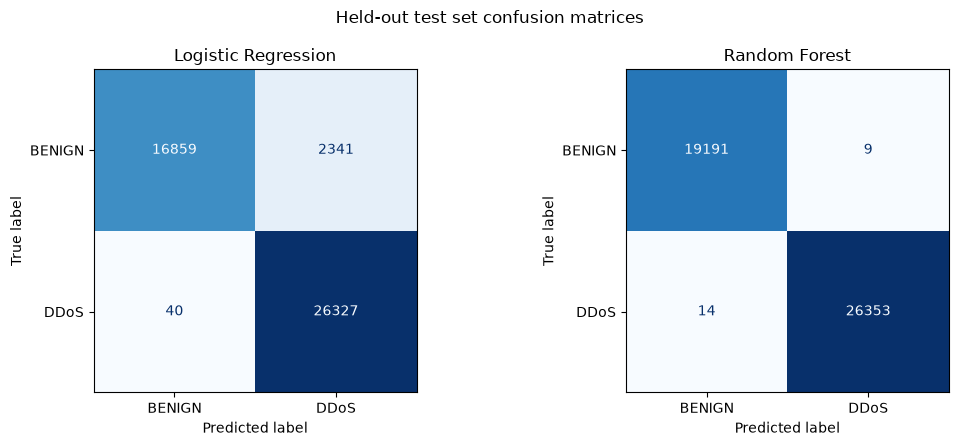

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, matrix, title in [
    (axes[0], logistic_matrix, "Logistic Regression"),
    (axes[1], forest_matrix, "Random Forest"),
]:
    ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=["BENIGN", "DDoS"],
    ).plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title(title)

fig.suptitle("Held-out test set confusion matrices")
plt.tight_layout()
plt.show()